<a href="https://colab.research.google.com/github/piyushjuneja21/Machine-Learning-Lab/blob/main/Placement_prediction_MLProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import SelectKBest, f_classif

Loading Dataset

In [ ]:
df = pd.read_csv("student_placement_prediction_dataset_2026.csv")


In [ ]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (100000, 26)

First 5 rows:


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


# Data Preprocessing

In [ ]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

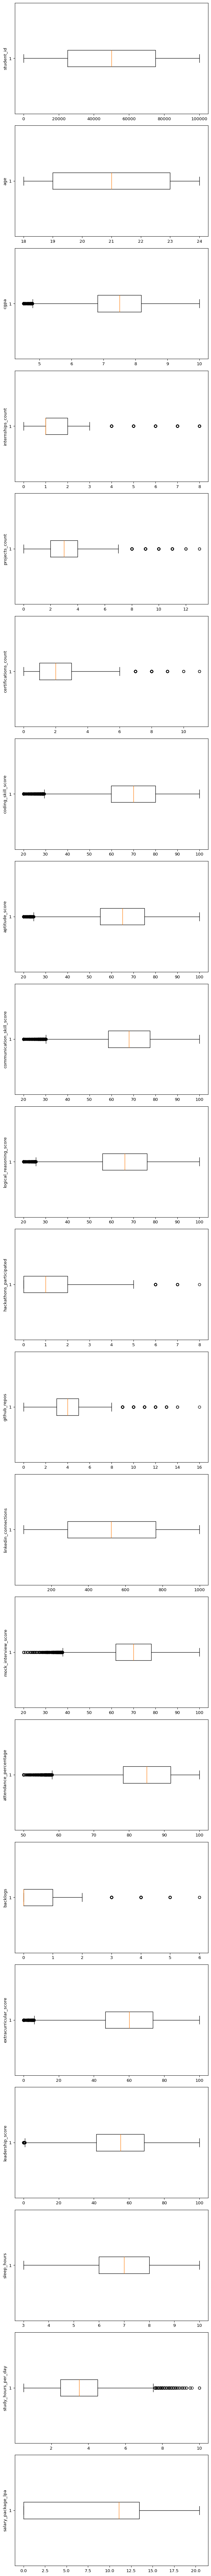

In [ ]:
import matplotlib.pyplot as plt

#Statistical Summary and Visualizing Outliers

df.describe()

numeric_cols = df.select_dtypes(include=np.number).columns

fig, axs = plt.subplots(len(numeric_cols), 1, figsize=(7, 4 * len(numeric_cols)), dpi=95)

# Adjust subplot creation for a single numeric column to avoid an error trying to index a single Axes object
if len(numeric_cols) == 1:
    axs = [axs] # Make axs iterable if there's only one subplot

for i, col in enumerate(numeric_cols):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
#Remove Outliers Using the Interquartile Range (IQR) Method

# Replace 'Insulin' with a valid numeric column from your DataFrame, e.g., 'salary_package_lpa'
column_to_clean = 'salary_package_lpa'

q1, q3 = np.percentile(df[column_to_clean], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df[column_to_clean] >= lower) & (df[column_to_clean] <= upper)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape after removing outliers from {column_to_clean}: {clean_df.shape}")


Original DataFrame shape: (100000, 26)
Cleaned DataFrame shape after removing outliers from salary_package_lpa: (100000, 26)


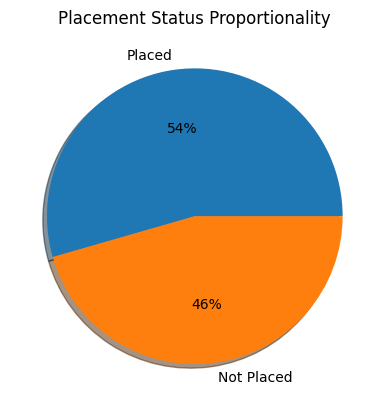

In [ ]:
#Visualize Target Variable Distribution

plt.pie(df['placement_status'].value_counts(), labels=df['placement_status'].value_counts().index, autopct='%.f%%', shadow=True)
plt.title('Placement Status Proportionality')
plt.show()

In [ ]:

#Prepare independent variables (features) and dependent variable (target) separately for modeling.

X = df.drop(columns=['placement_status'])
y = df['placement_status']


In [ ]:
df=df.dropna()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [ ]:

X = df.drop('placement_status', axis=1)  # target column name change if needed
y = df['placement_status']

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
#X → input features
#y → target (what you want to predict)
#test_size=0.2 → 20% data for testing
#X_train, y_train → used to train model

# Model Training

In [ ]:
# =========================
# Logistic Regression Model Training
# =========================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Feature Scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'   # helps if slight imbalance exists
)

# Train model
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# =========================
# Evaluation
# =========================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[ 9127     0]
 [    0 10873]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9127
           1       1.00      1.00      1.00     10873

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

